# Clustering Project

**Deadline for submission: 17/3/2026 @ 11:59 PM**


Please make sure to explain your work using comments whenever possible.

**Objective:**
The objective of this project is to teach students how to apply clustering to real datasets.

You should be able to answer the following questions and provide reasonable justification for your answers:
* Which clustering approach have you decided to use on each dataset?
* Compare between Kmeans, Hierarchal and DBScan.
* Discuss how you tuned your clustering hyperparameters to achieve the best cluster assignment?
* What is the effect of different distance functions on the calculated clusters?
* How did you evaluate the performance of different clustering techniques on different datatsets?
* Visualize your output where applicable.
* What is the effect of scaling on the performance of clustering techniques?






Running this project requires the following imports:

In [15]:
import warnings
warnings.filterwarnings('ignore')
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import sklearn.preprocessing as prep
from sklearn.datasets import make_blobs

# StandardScaler is a function to normalize the data
# You may also check MinMaxScaler and MaxAbsScaler
#from sklearn.preprocessing import StandardScaler

from sklearn.cluster import DBSCAN


from sklearn.cluster import KMeans

from sklearn.metrics import silhouette_score

%matplotlib inline
# Please refer to the sklearn documentation to learn more about the different parameters for each clustering technique.

In [16]:
# helper function that allows us to display data in 2 dimensions an highlights the clusters
def display_cluster(X,km=[],num_clusters=0):
    color = 'brgcmyk'  #List colors
    alpha = 0.5
    s = 20
    if num_clusters == 0:
        plt.scatter(X[:,0],X[:,1],c = color[0],alpha = alpha,s = s)
    else:
        for i in range(num_clusters):
            plt.scatter(X[km.labels_==i,0],X[km.labels_==i,1],c = color[i],alpha = alpha,s=s)
            plt.scatter(km.cluster_centers_[i][0],km.cluster_centers_[i][1],c = color[i], marker = 'x', s = 100)

## Multi Blob Data Set
* The dataset generated below is known to be best clustered into 6 clusters.
* Cluster the data set below using the three different clustering techniques discussed in the course.
* Visualize your clustering output in each step of your work.



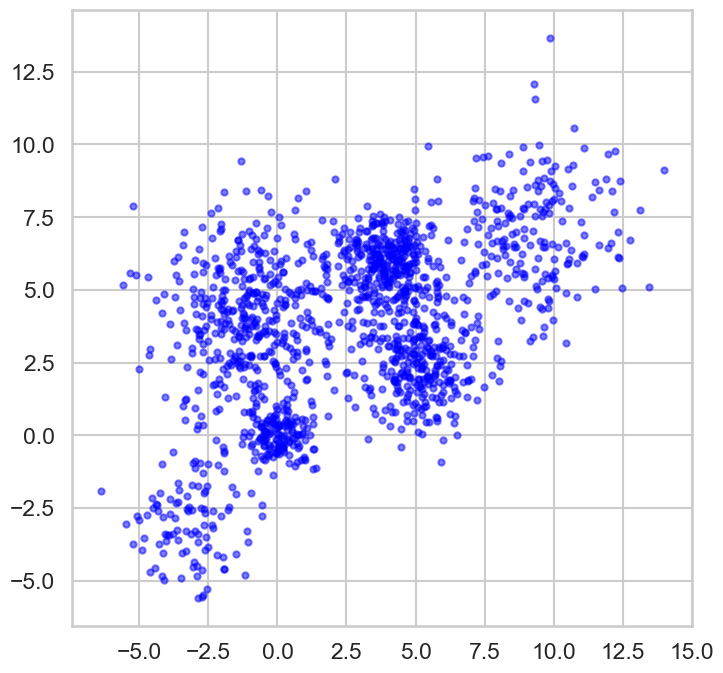

In [17]:
#Data Generation and Visualization
plt.rcParams['figure.figsize'] = [8,8]
sns.set_style("whitegrid")
sns.set_context("talk")

n_bins = 6
centers = [(-3, -3), (0, 0), (5,2.5),(-1, 4), (4, 6), (9,7)]
Multi_blob_Data, y = make_blobs(n_samples=[100,150, 300, 400,300, 200], n_features=2, cluster_std=[1.3,0.6, 1.2, 1.7,0.9,1.7],
                  centers=centers, shuffle=False, random_state=42)
display_cluster(Multi_blob_Data)

### Kmeans
* Use Kmeans with different values of K to cluster the above data.
* Display the outcome of each value of K.
* Plot distortion function versus K and choose the approriate value of K.
* Plot the silhouette_score versus K and use it to choose the best K.
* Store the silhouette_score for the best K for later comparison with other clustering techniques.
* Comment on the effect of centroid initialization on cluster assignment.
* Hint: Lookup k-means++ .

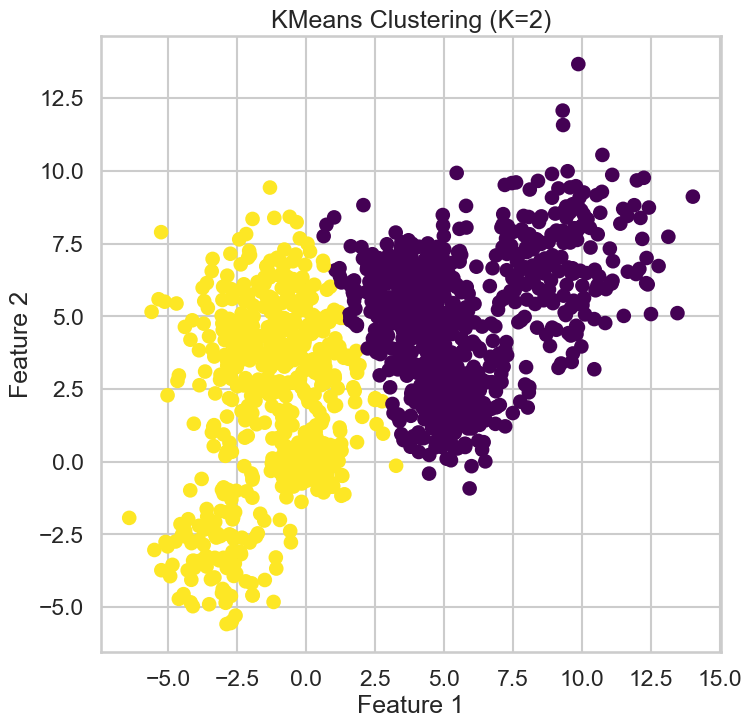

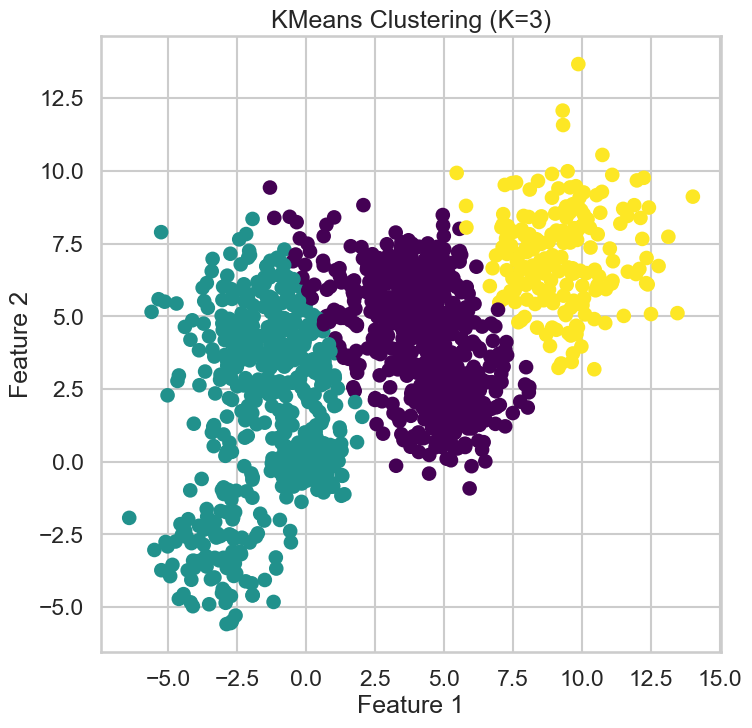

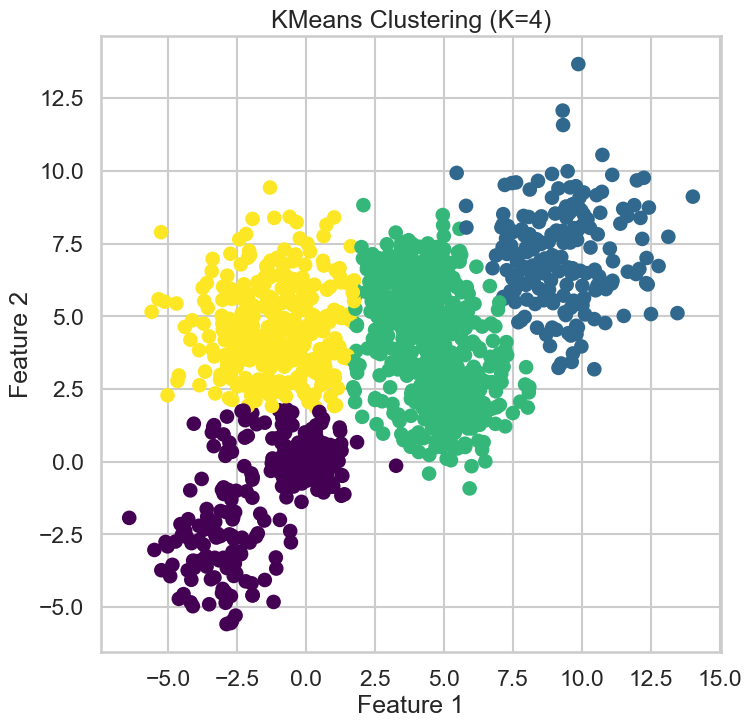

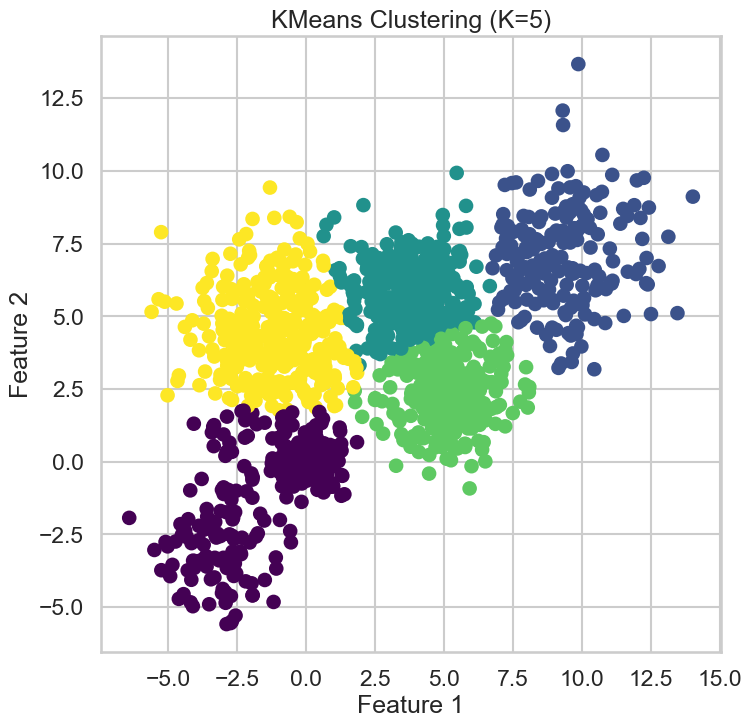

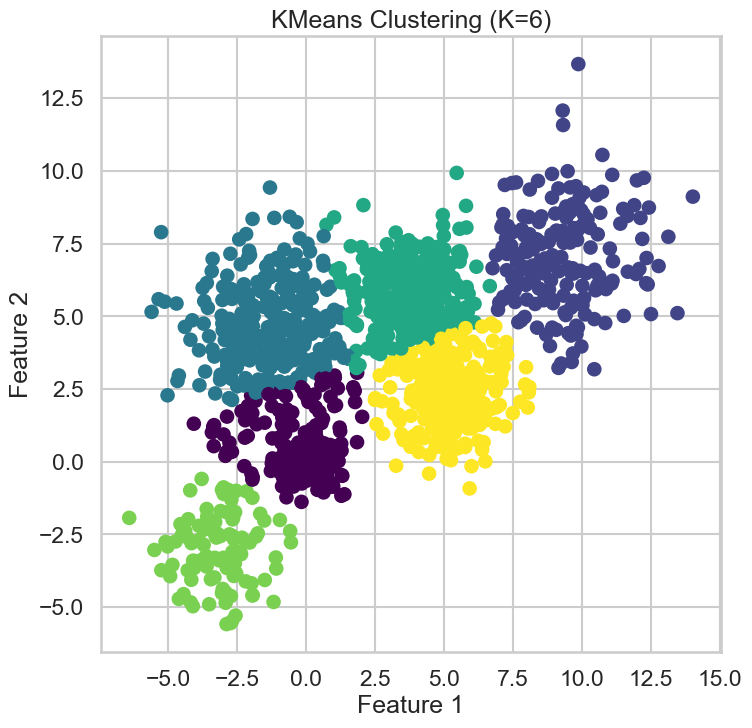

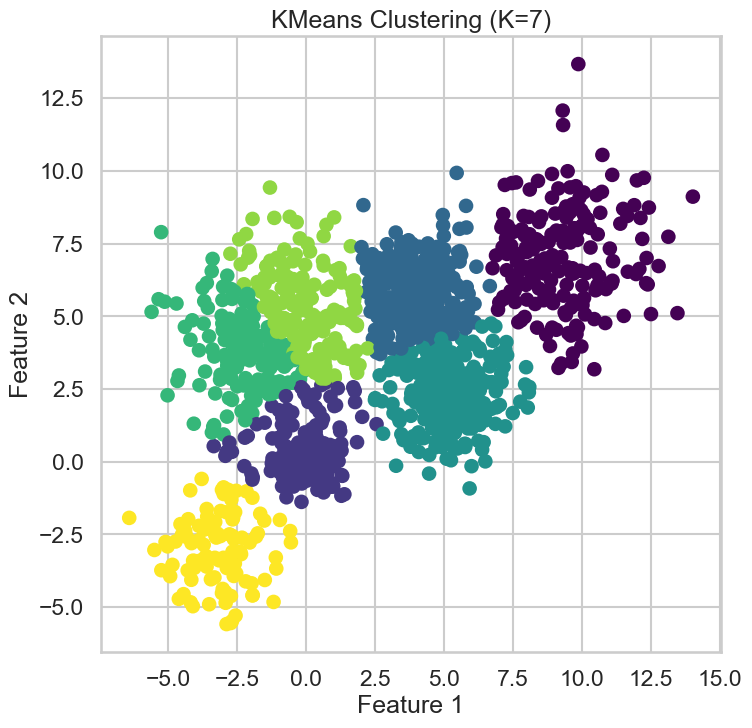

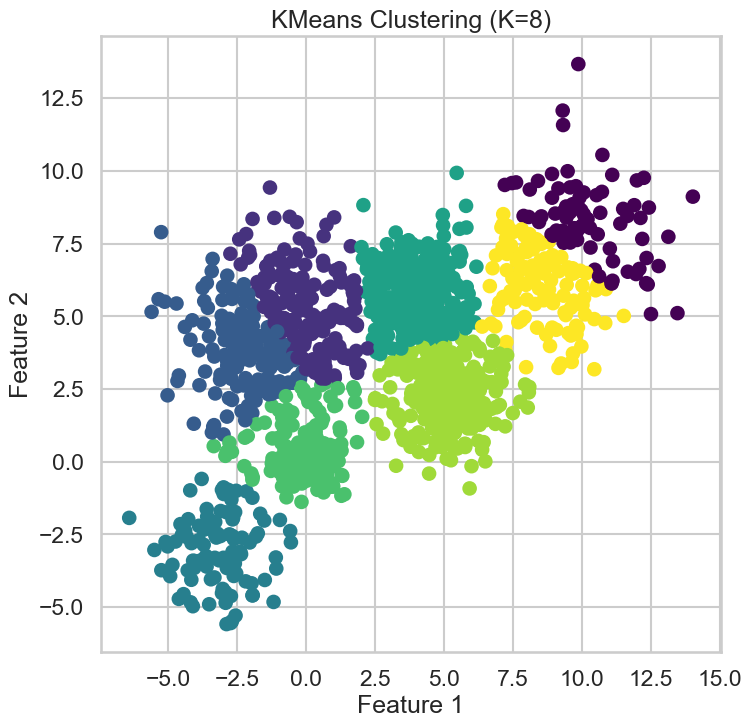

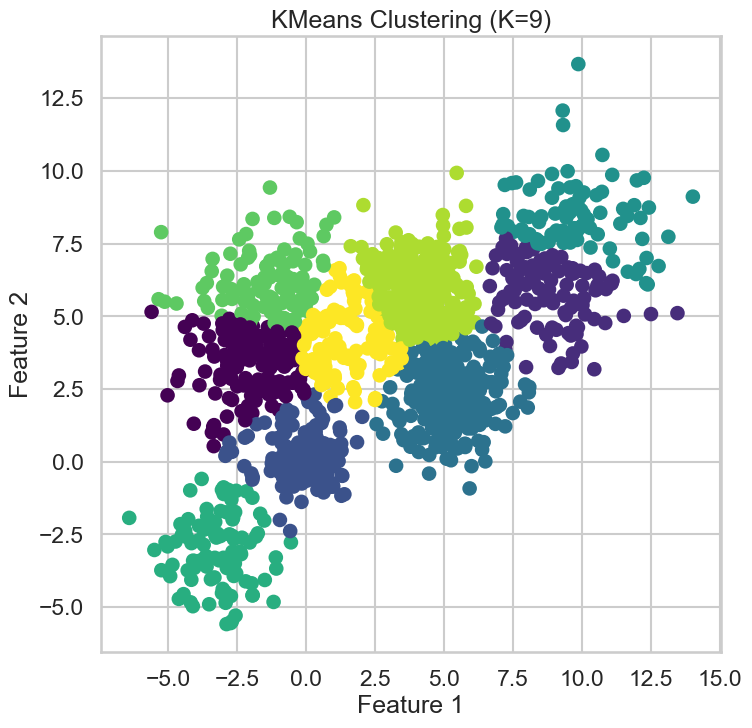

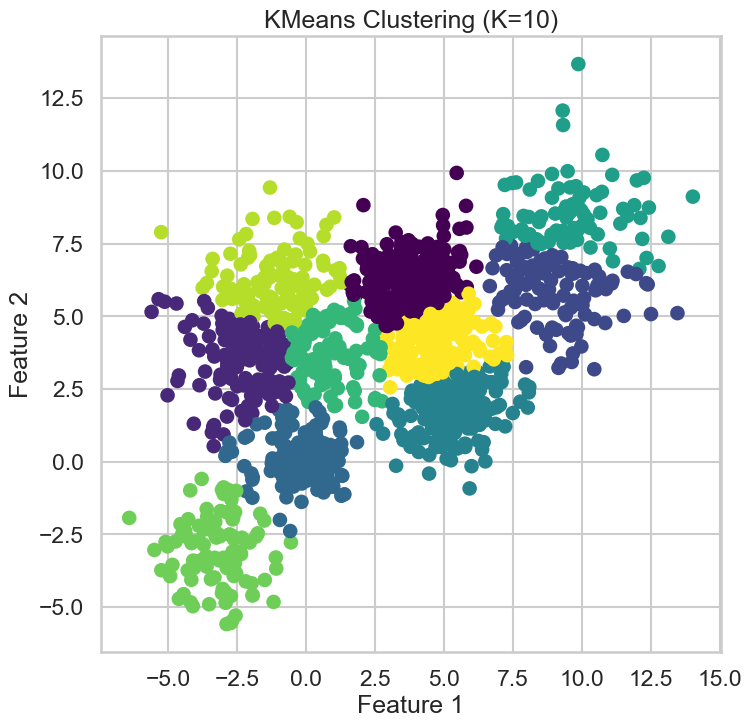

In [26]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

K_range = range(2,11)

distortion = []
sil_scores = []

for k in K_range:
    
    model = KMeans(n_clusters=k, init='k-means++', random_state=42)
    labels = model.fit_predict(Multi_blob_Data)

    distortion.append(model.inertia_)
    sil_scores.append(silhouette_score(Multi_blob_Data, labels))
    

    plt.figure()
    plt.scatter(Multi_blob_Data[:,0], Multi_blob_Data[:,1], c=labels, cmap="viridis")
    plt.title(f"KMeans Clustering (K={k})")
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.show()

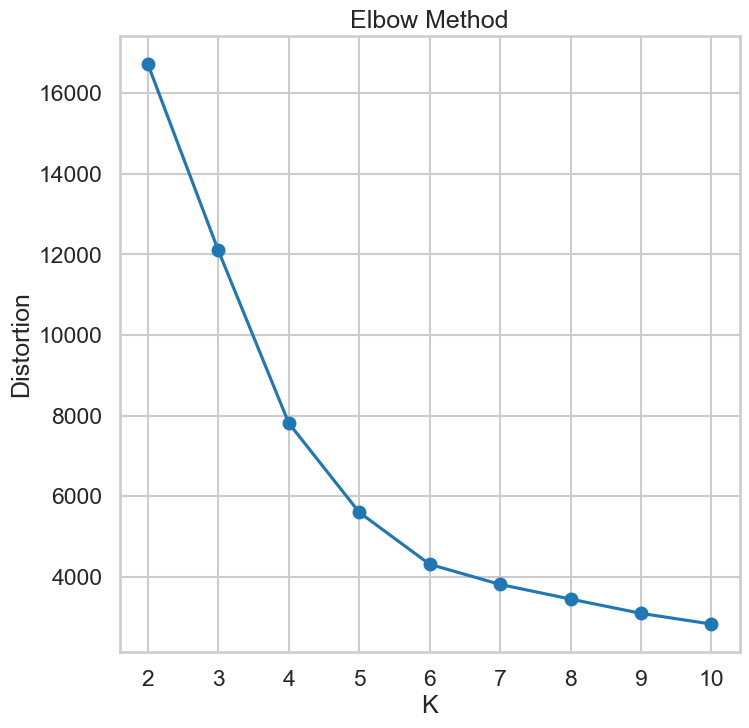

In [20]:
plt.plot(K_range, distortion, marker='o')
plt.xlabel("K")
plt.ylabel("Distortion")
plt.title("Elbow Method")
plt.show()

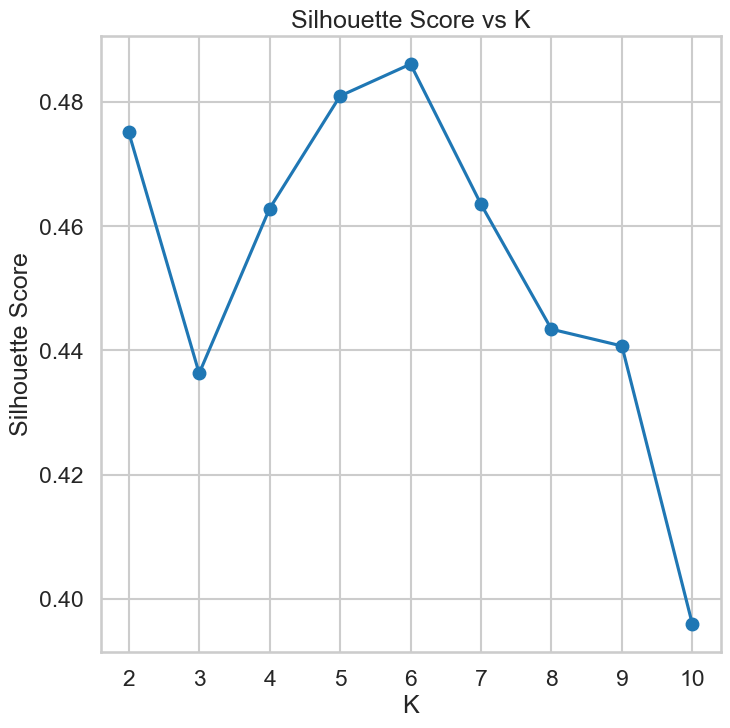

In [21]:
plt.plot(K_range, sil_scores, marker='o')
plt.xlabel("K")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score vs K")
plt.show()

In [ ]:
best_k = K_range[sil_scores.index(max(sil_scores))]
best_silhouette_kmeans = max(sil_scores)

The initialization of centroids significantly affects the performance of the K-Means algorithm because it may converge to different local minima depending on the starting points. Random initialization can lead to unstable clustering results and slower convergence. To address this issue, the k-means++ initialization method is used. k-means++ selects the initial centroids in a way that spreads them across the dataset by choosing new centroids with probability proportional to their distance from existing centroids. This approach generally improves clustering quality, reduces distortion, and accelerates convergence.

### Hierarchal Clustering
* Use AgglomerativeClustering function to  to cluster the above data.
* In the  AgglomerativeClustering change the following parameters:
    * Affinity (use euclidean, manhattan and cosine)
    * Linkage(try different options)
    * Distance_threshold (try different options)
* Plot the dendrograph for one trial.
* For each of these trials, calculate the silhouette_score and display the resulting clusters.  
* Find the set of paramters that would find result in the best silhouette_score and store this score for later comparison with other clustering techniques.
* Record your observation.

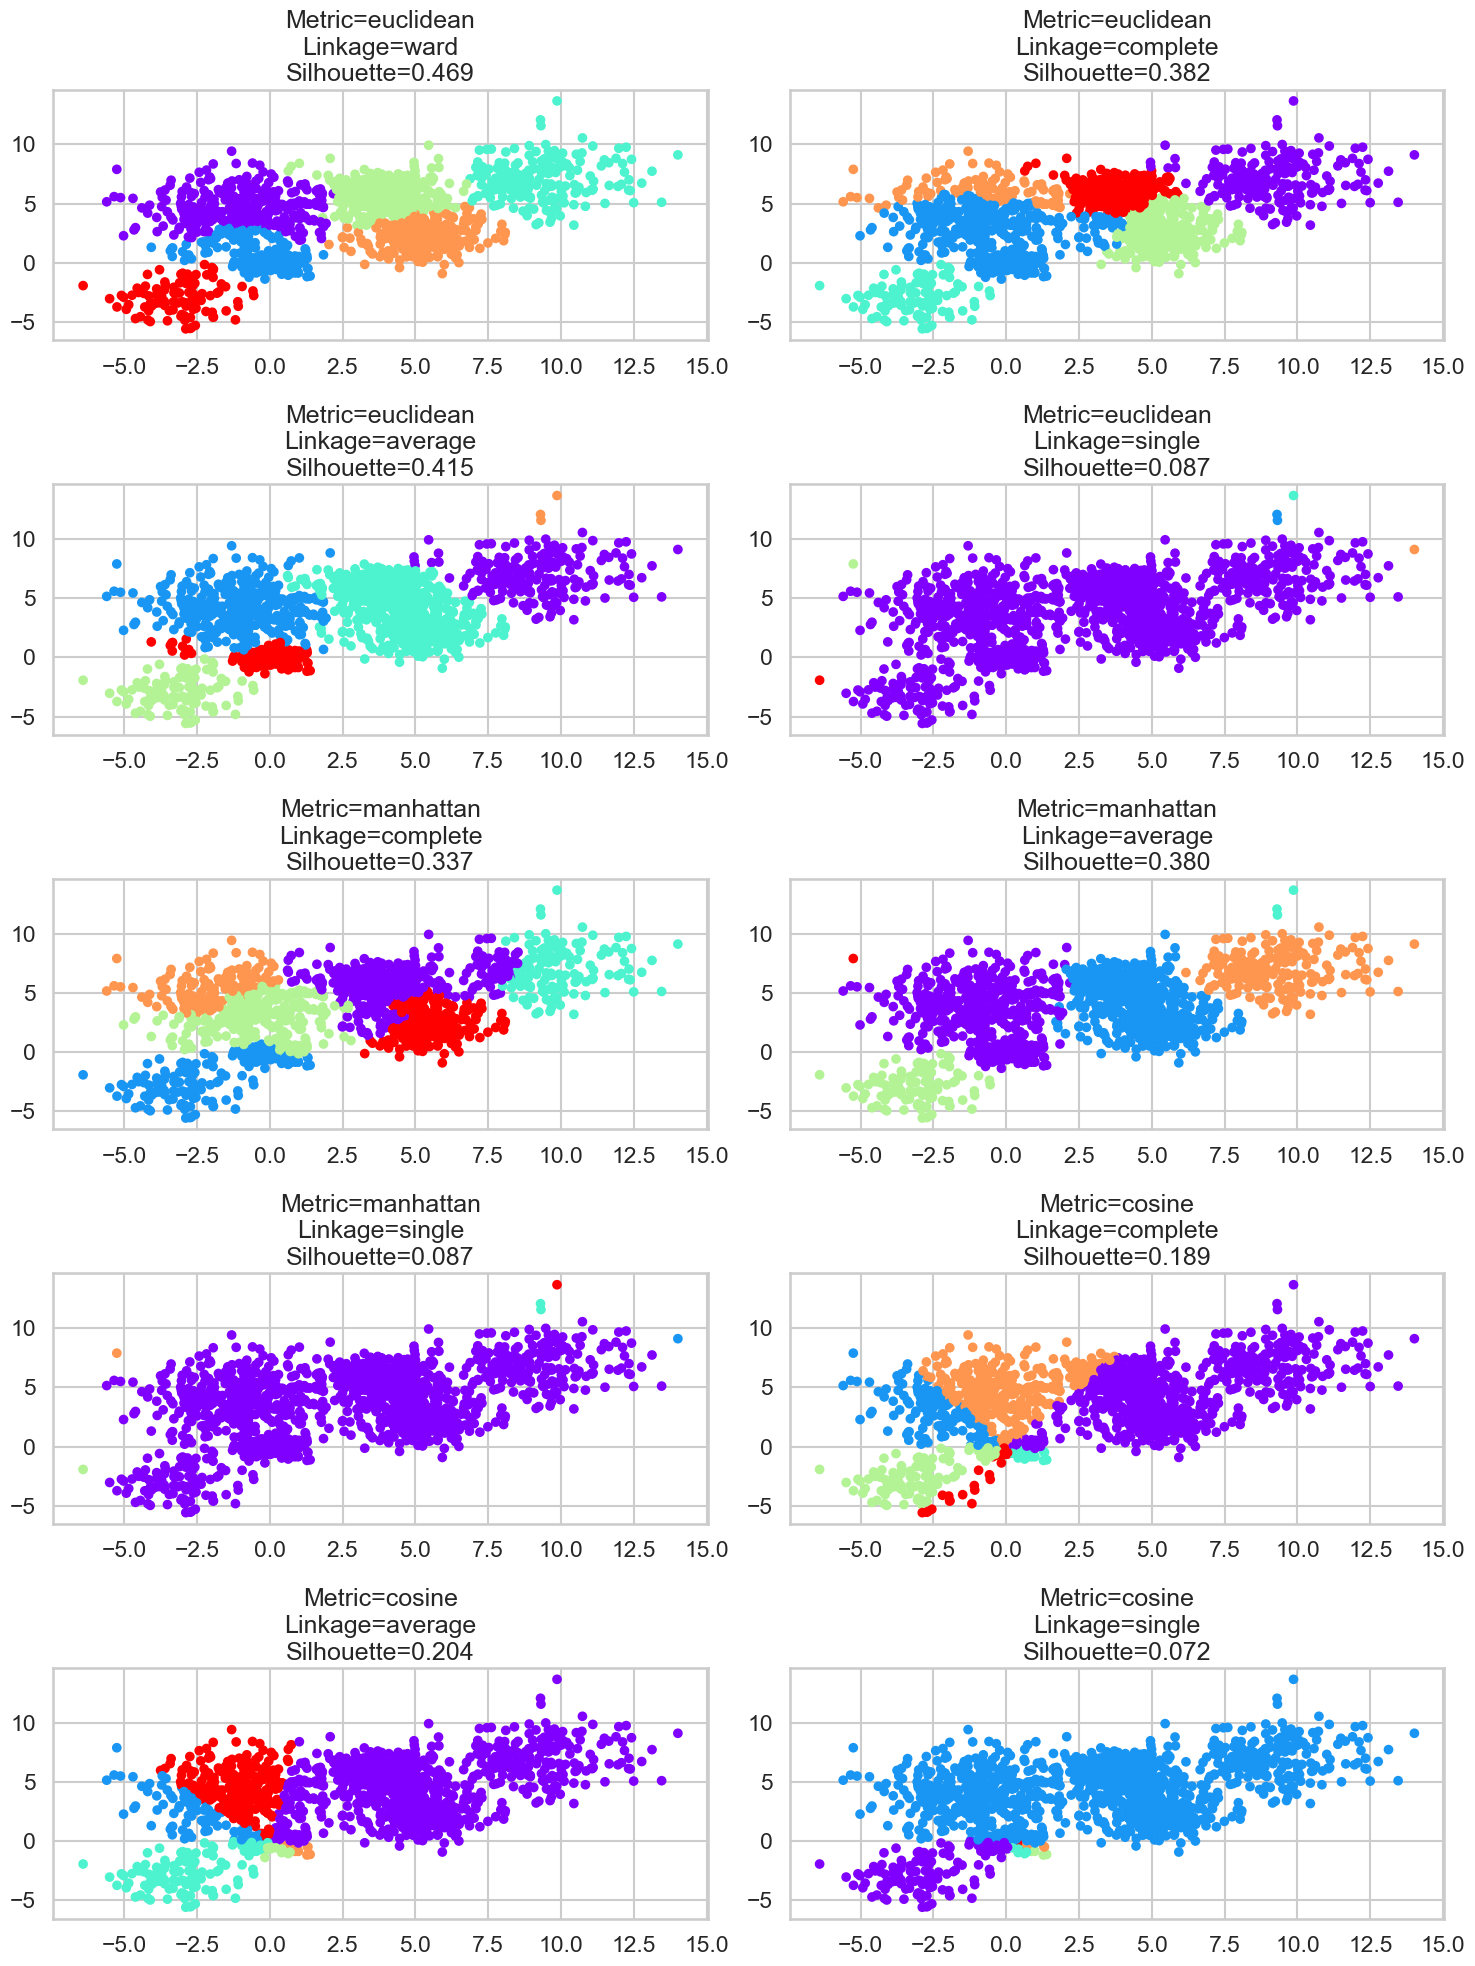

In [108]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
import math

metrics = ['euclidean', 'manhattan', 'cosine']
linkages = ['ward', 'complete', 'average', 'single']

results = []
plots = []

for metric in metrics:
    for link in linkages:
        
        # ward only works with euclidean
        if link == "ward" and metric != "euclidean":
            continue
        
        model = AgglomerativeClustering(
            n_clusters=6,
            metric=metric,
            linkage=link
        )
        
        labels = model.fit_predict(Multi_blob_Data)
        
        score = silhouette_score(Multi_blob_Data, labels)
        
        results.append((metric, link, score))
        plots.append((metric, link, score, labels))


# ----- GRID PLOTTING -----

n_plots = len(plots)
cols = 2
rows = math.ceil(n_plots / cols)

fig, axes = plt.subplots(rows, cols, figsize=(15, rows*4))
axes = axes.flatten()

for i, (metric, link, score, labels) in enumerate(plots):

    axes[i].scatter(
        Multi_blob_Data[:,0],
        Multi_blob_Data[:,1],
        c=labels,
        cmap="rainbow",
        s=30
    )

    axes[i].set_title(
        f"Metric={metric}\nLinkage={link}\nSilhouette={score:.3f}"
    )

# Remove empty plots if needed
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [109]:
best = max(results, key=lambda x: x[2])
print("Best Parameters:")
print("Metric:", best[0])
print("Linkage:", best[1])
print("Best Silhouette Score:", best[2])

Best Parameters:
Metric: euclidean
Linkage: ward
Best Silhouette Score: 0.4686938472105883


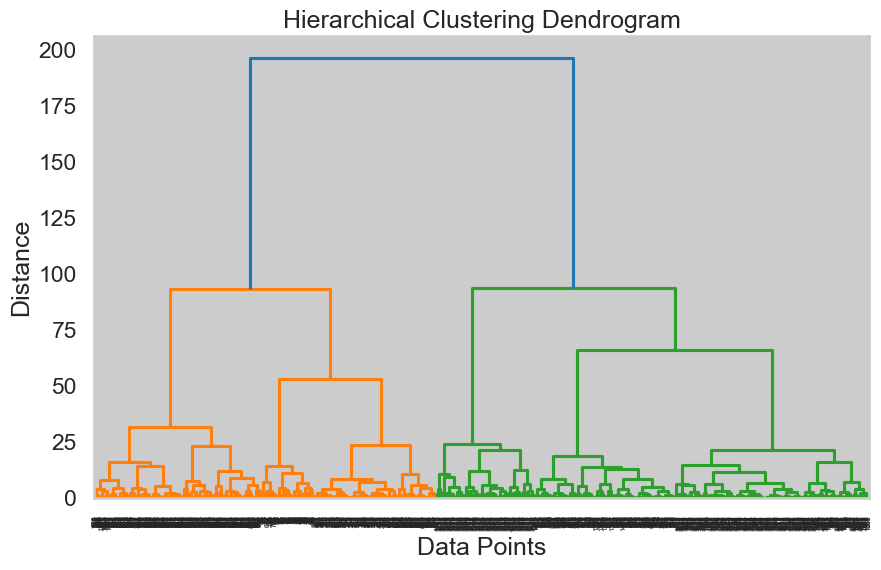

In [110]:
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt

linked = linkage(Multi_blob_Data, method='ward', metric='euclidean')

plt.figure(figsize=(10,6))
dendrogram(linked)
plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Data Points")
plt.ylabel("Distance")
plt.show()

In [31]:
model = AgglomerativeClustering(
    n_clusters=6,
    metric='euclidean',
    linkage='ward'
)

labels = model.fit_predict(Multi_blob_Data)

In [32]:
from sklearn.metrics import silhouette_score

score = silhouette_score(Multi_blob_Data, labels)
print(score)

0.4686938472105883


### DBScan
* Use DBScan function to  to cluster the above data.
* In the  DBscan change the following parameters:
    * EPS (from 0.1 to 3)
    * Min_samples (from 5 to 25)

* Plot the silhouette_score versus the variation in the EPS and the min_samples.
* Plot the resulting Clusters in this case.
* Find the set of paramters that would find result in the best silhouette_score and store this score for later comparison with other clustering techniques.
* Record your observations and comments.

In [36]:
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score
import numpy as np
import matplotlib.pyplot as plt
eps_values = np.arange(0.1, 3.1, 0.2)
min_samples_values = range(5, 26)
results = []

for eps in eps_values:
    for min_s in min_samples_values:
        
        db = DBSCAN(eps=eps, min_samples=min_s)
        labels = db.fit_predict(Multi_blob_Data)
        
        unique_labels = set(labels)
        
        # allow noise but require at least 2 clusters
        if len(unique_labels - {-1}) >= 2:
            
            score = silhouette_score(Multi_blob_Data, labels)
            results.append((eps, min_s, score))

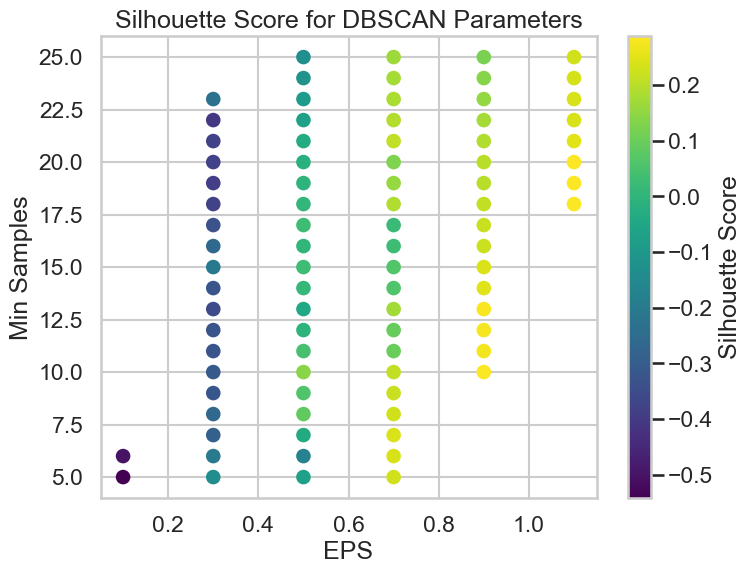

In [37]:
eps_list = [r[0] for r in results]
min_samples_list = [r[1] for r in results]
scores = [r[2] for r in results]
plt.figure(figsize=(8,6))

scatter = plt.scatter(eps_list, min_samples_list,
                      c=scores, cmap='viridis')

plt.xlabel("EPS")
plt.ylabel("Min Samples")
plt.title("Silhouette Score for DBSCAN Parameters")
plt.colorbar(scatter, label="Silhouette Score")

plt.show()

In [38]:
best = max(results, key=lambda x: x[2])

best_eps = best[0]
best_min_samples = best[1]
best_silhouette_dbscan = best[2]

print("Best EPS:", best_eps)
print("Best min_samples:", best_min_samples)
print("Best Silhouette Score:", best_silhouette_dbscan)

Best EPS: 1.1000000000000003
Best min_samples: 20
Best Silhouette Score: 0.28834980935107746


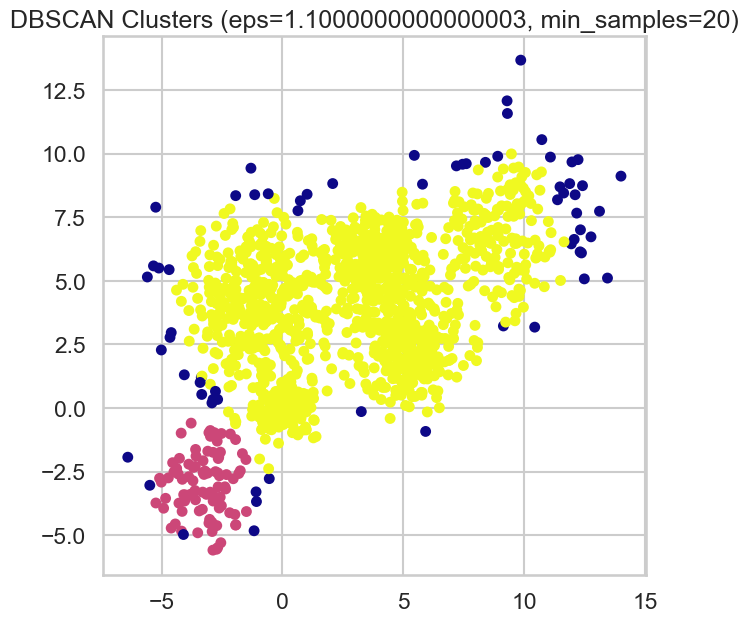

In [39]:
db = DBSCAN(eps=best_eps, min_samples=best_min_samples)

labels = db.fit_predict(Multi_blob_Data)

plt.figure(figsize=(7,7))
plt.scatter(Multi_blob_Data[:,0], Multi_blob_Data[:,1],
            c=labels, cmap="plasma", s=40)

plt.title(f"DBSCAN Clusters (eps={best_eps}, min_samples={best_min_samples})")
plt.show()

## iris data set
The iris data set is test data set that is part of the Sklearn module
which contains 150 records each with 4 features. All the features are represented by real numbers.

The data represents three classes.


In [ ]:
from sklearn.datasets import load_iris
iris_data = load_iris()
iris_data.target[[10, 25, 50]]
#array([0, 0, 1])
list(iris_data.target_names)
['setosa', 'versicolor', 'virginica']


['setosa', 'versicolor', 'virginica']

* Repeat all the above clustering approaches and steps on the above data.
* Comment on the effect of scaling on clustering this dataset. Show the difference between clustering the data with and without   scaling.
* Compare between the different clustering approaches.
* Is your clustering outcome consistent with the labels?

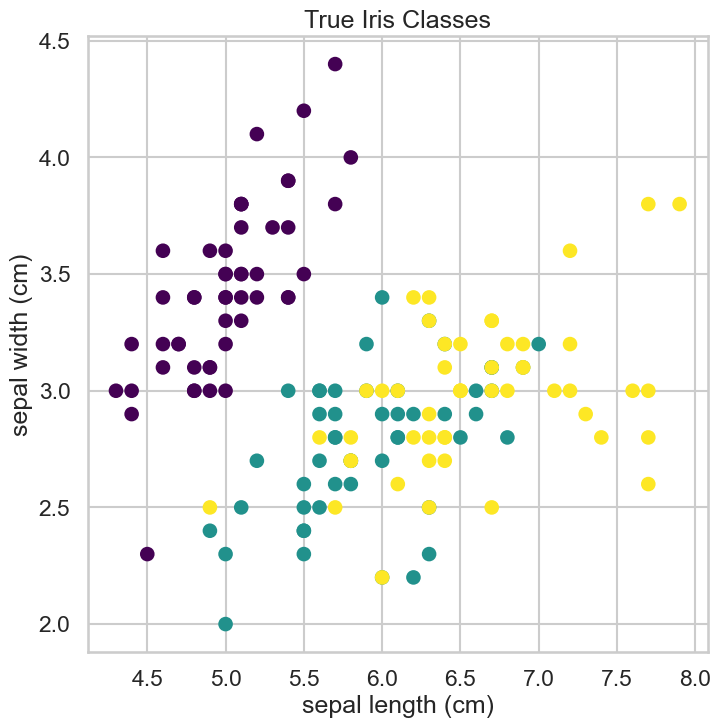

In [41]:
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
import pandas as pd
#visualise the dataset
iris = load_iris()

X = iris.data
y_true = iris.target
feature_names = iris.feature_names
plt.scatter(X[:,0], X[:,1], c=y_true, cmap="viridis")
plt.xlabel(feature_names[0])
plt.ylabel(feature_names[1])
plt.title("True Iris Classes")
plt.show()

## Kmeans

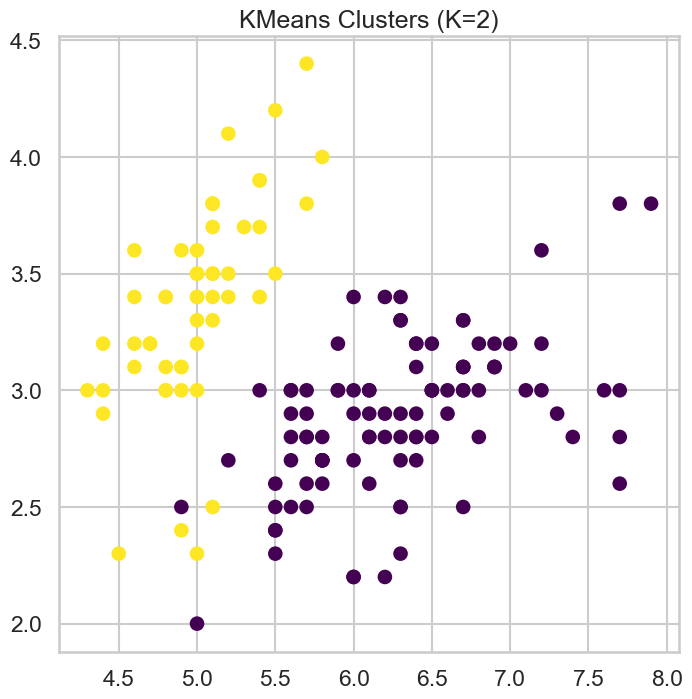

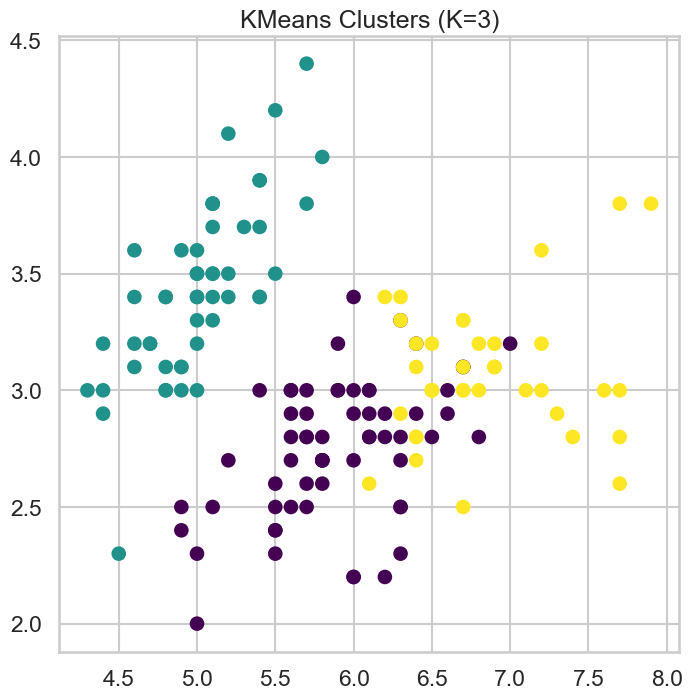

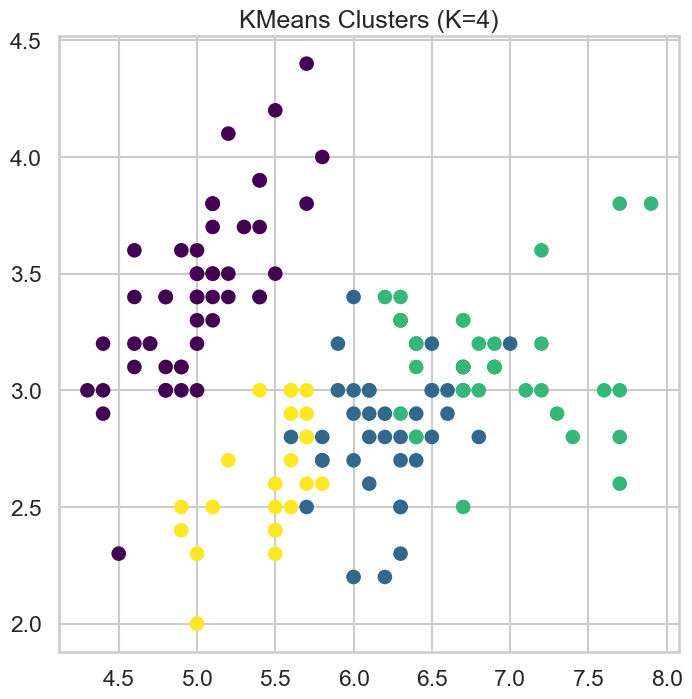

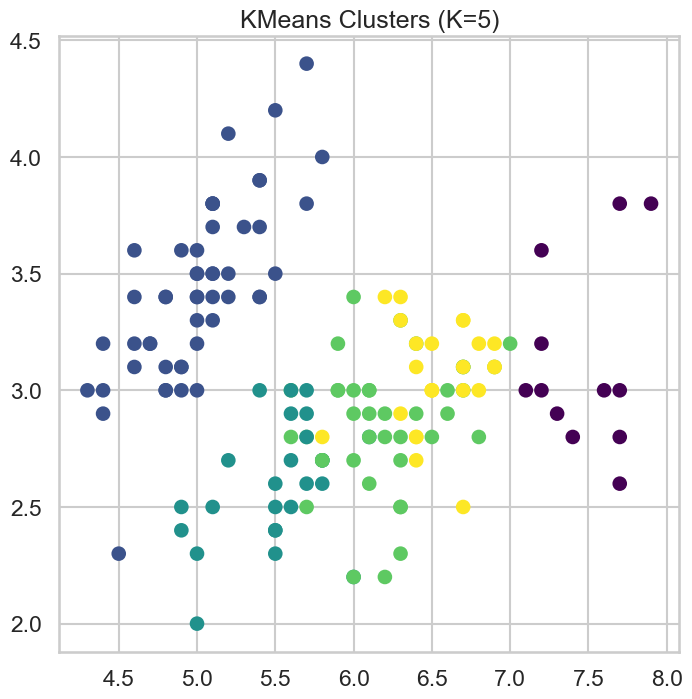

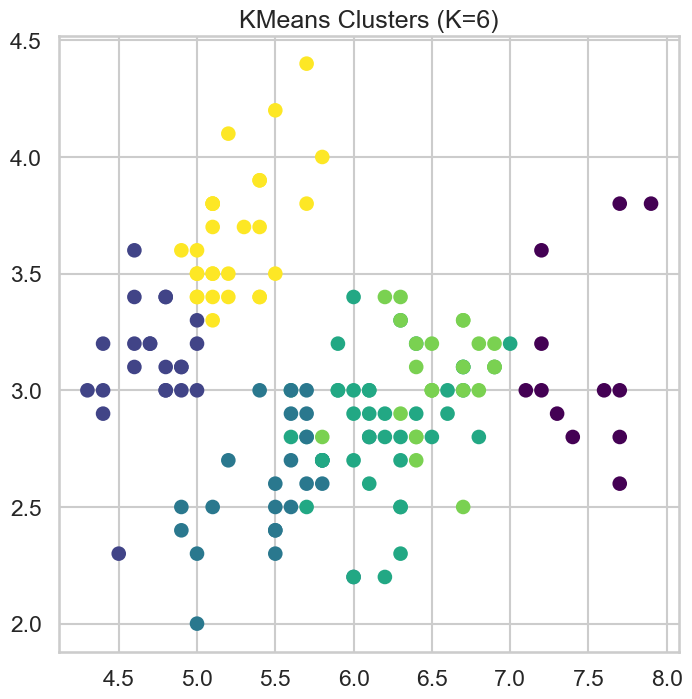

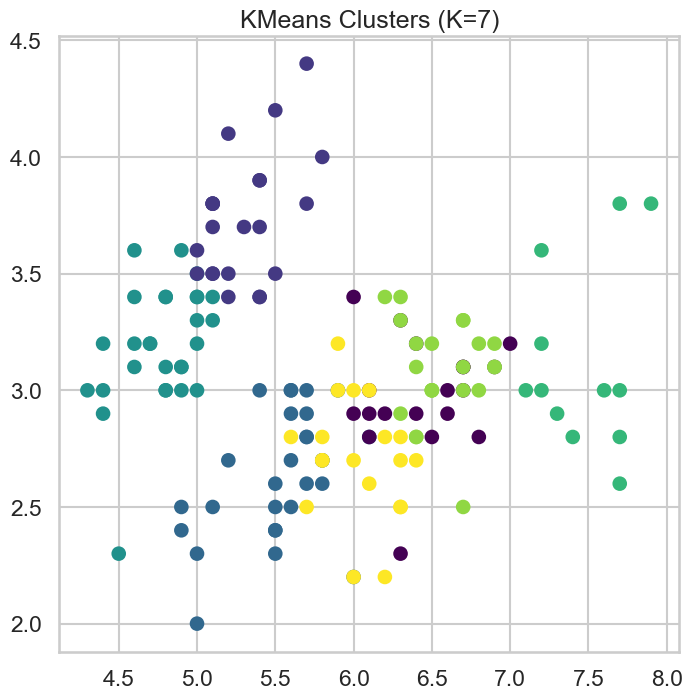

In [54]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

K_range = range(2,8)

distortion = []
sil_scores = []

for k in K_range:
    
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42)
    labels = kmeans.fit_predict(X)
    
    distortion.append(kmeans.inertia_)
    sil_scores.append(silhouette_score(X, labels))
    plt.scatter(X[:,0], X[:,1], c=labels, cmap='viridis')
    plt.title(f"KMeans Clusters (K={k})")
    plt.show()

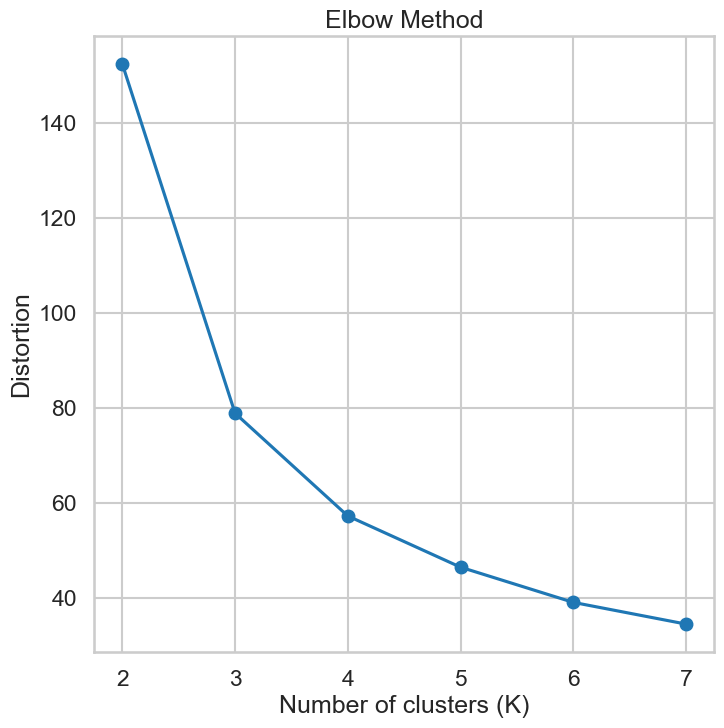

In [55]:
plt.plot(K_range, distortion, marker='o')
plt.xlabel("Number of clusters (K)")
plt.ylabel("Distortion")
plt.title("Elbow Method")
plt.show()

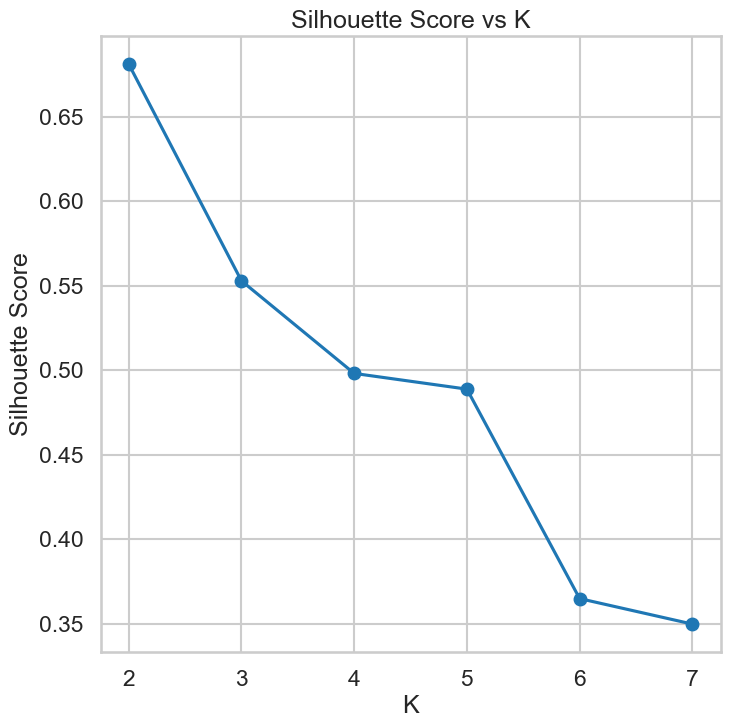

In [56]:
plt.plot(K_range, sil_scores, marker='o')
plt.xlabel("K")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score vs K")
plt.show()

we will choose 3 clusters as the elbow method suggests although it is not the highest sillouette score but logically it is more correct because the iris dataset actually has 3 clusters

Adjusted Rand Index: 0.7302382722834697


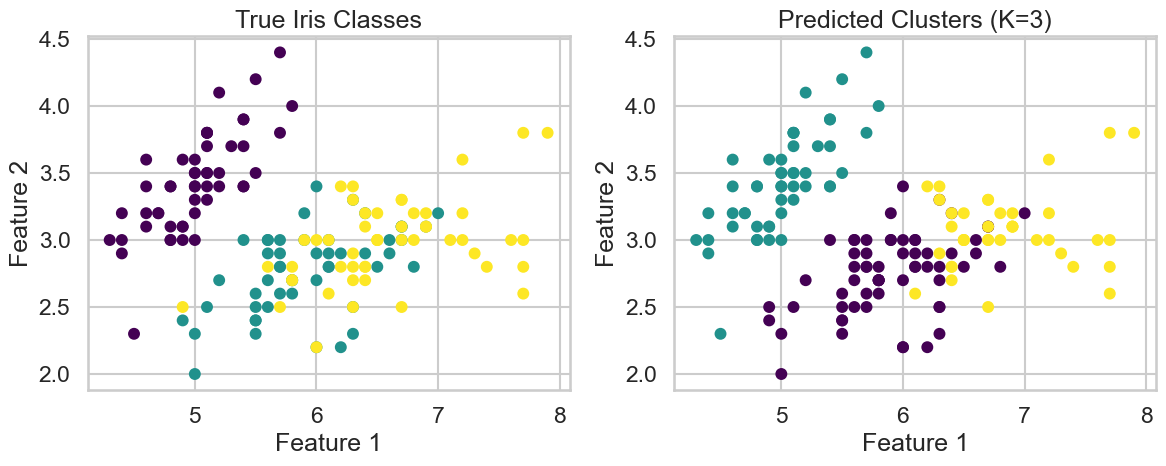

In [62]:
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score
import matplotlib.pyplot as plt

# Run clustering
k = 3
model = KMeans(n_clusters=k, random_state=42)
labels = model.fit_predict(X)

# Evaluate
ari = adjusted_rand_score(y_true, labels)
print("Adjusted Rand Index:", ari)

# Plot comparison
plt.figure(figsize=(12,5))

# True labels
plt.subplot(1,2,1)
plt.scatter(X[:,0], X[:,1], c=y_true, cmap='viridis', s=50)
plt.title("True Iris Classes")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")

# Predicted clusters
plt.subplot(1,2,2)
plt.scatter(X[:,0], X[:,1], c=labels, cmap='viridis', s=50)
plt.title("Predicted Clusters (K=3)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")

plt.tight_layout()
plt.show()

## Scaling

In [64]:
from sklearn.preprocessing import StandardScaler

kmeans = KMeans(n_clusters=3)
labels_no_scale = kmeans.fit_predict(X)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kmeans = KMeans(n_clusters=3)
labels_scaled = kmeans.fit_predict(X_scaled)
#compare with and without scaling
score_no_scale = silhouette_score(X, labels_no_scale)
score_scaled = silhouette_score(X_scaled, labels_scaled)

print(score_no_scale, score_scaled)

0.5528190123564095 0.45994823920518635


This indicates that clustering performance slightly decreased after scaling. This occurs because the original feature scales already preserve meaningful differences between the variables, particularly the petal measurements, which are highly informative for separating the Iris classes.

## Agglomerative

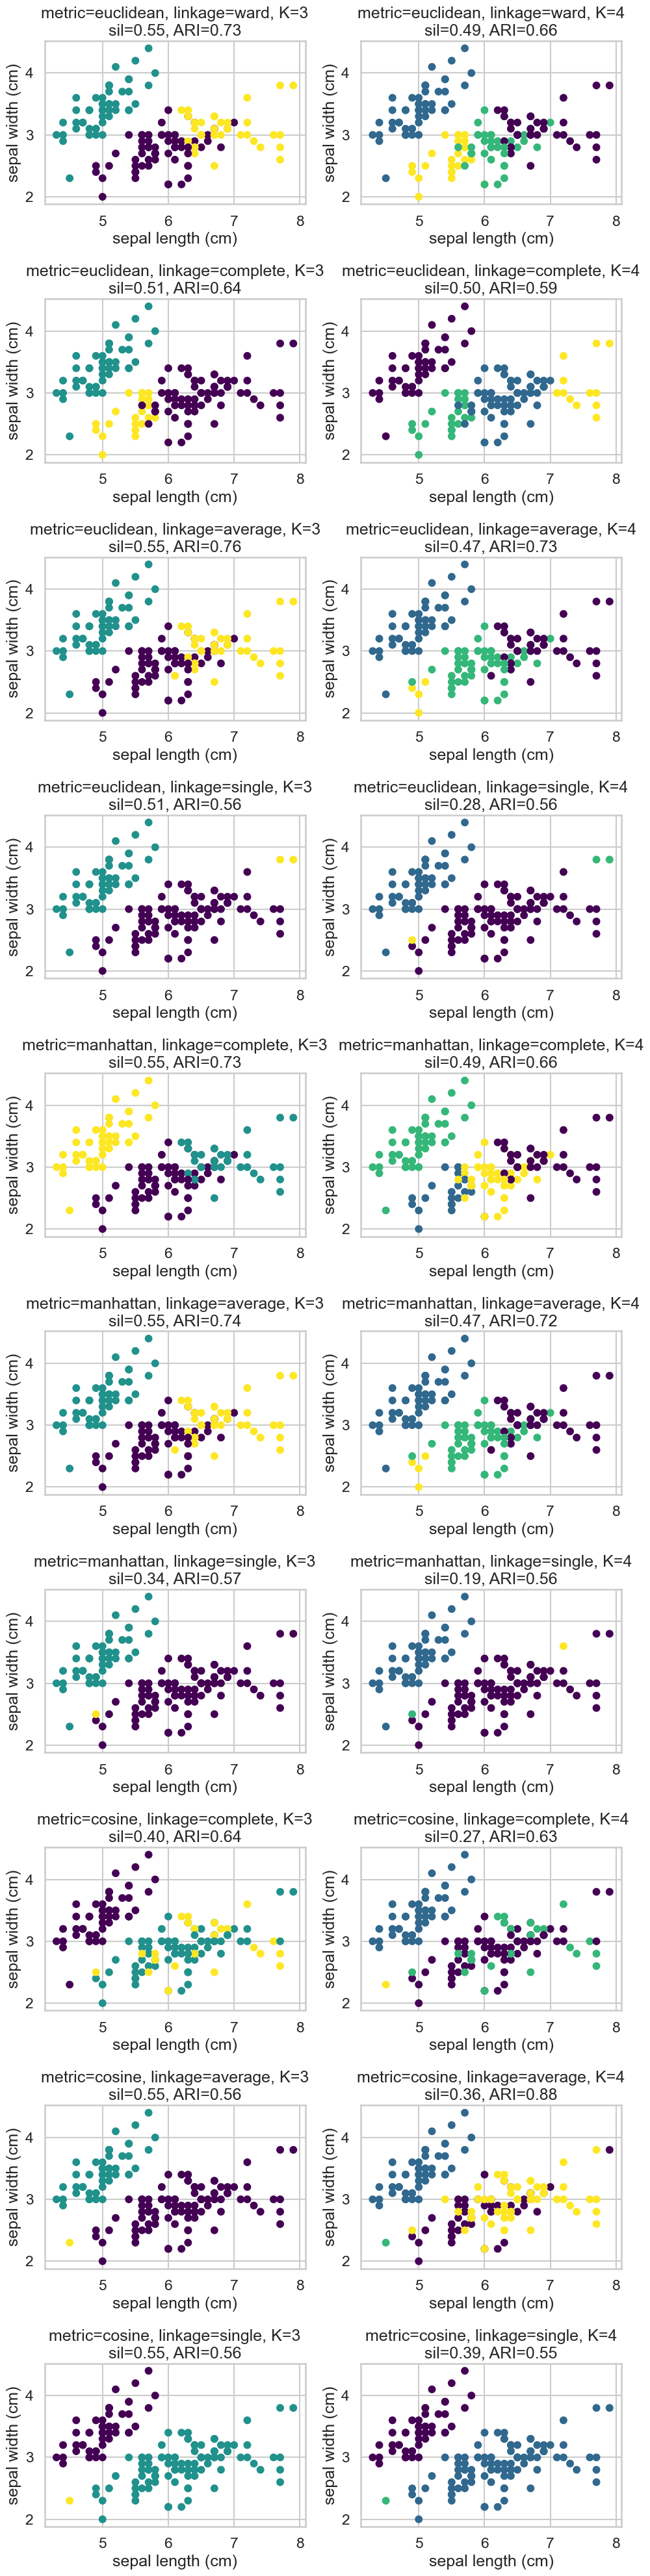

In [199]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score, adjusted_rand_score
import matplotlib.pyplot as plt
import math

metrics = ['euclidean', 'manhattan', 'cosine']
linkages = ['ward', 'complete', 'average', 'single']
Ks = range(3,5)

results = []

plots = []

for metric in metrics:
    for link in linkages:
        for k in Ks:
            
            if link == 'ward' and metric != 'euclidean':
                continue
            
            try:
                model = AgglomerativeClustering(
                    n_clusters=k,
                    metric=metric,
                    linkage=link
                )
                
                labels = model.fit_predict(X)
                
                sil_score = silhouette_score(X, labels)
                ari_score = adjusted_rand_score(y_true, labels)
                
                results.append((metric, link, k, sil_score, ari_score))
                plots.append((metric, link, k, sil_score, ari_score, labels))
            
            except Exception:
                continue


# ----- GRID PLOTTING -----

n_plots = len(plots)
cols = 2
rows = math.ceil(n_plots / cols)

fig, axes = plt.subplots(rows, cols, figsize=(10, rows*4))
axes = axes.flatten()

for i, (metric, link, k, sil, ari, labels) in enumerate(plots):

    axes[i].scatter(X[:,0], X[:,1], c=labels, cmap='viridis', s=50)
    axes[i].set_title(
        f"metric={metric}, linkage={link}, K={k}\n"
        f"sil={sil:.2f}, ARI={ari:.2f}"
    )
    axes[i].set_xlabel(iris.feature_names[0])
    axes[i].set_ylabel(iris.feature_names[1])

# remove empty subplots if any
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [200]:
best = max(results, key=lambda x: x[3])

best_metric = best[0]
best_linkage = best[1]
best_k = best[2]
best_silhouette = best[3]
best_ari = best[4]

print("Best metric:", best_metric)
print("Best linkage:", best_linkage)
print("Best K:", best_k)
print("Silhouette score:", best_silhouette)
print("Best ARI:", best_ari)

Best metric: manhattan
Best linkage: complete
Best K: 3
Silhouette score: 0.5543665902228473
Best ARI: 0.7322981167185344


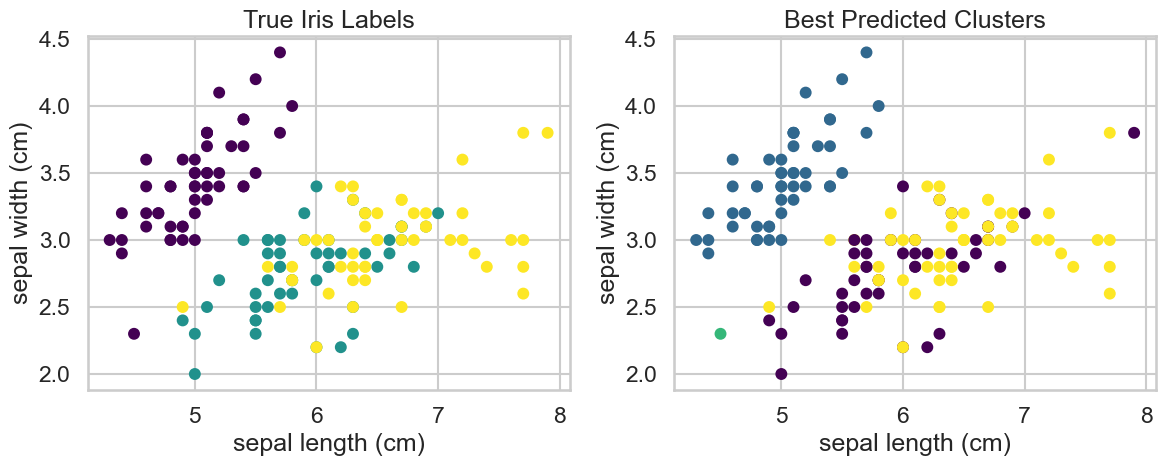

In [93]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(X[:, 0], X[:, 1], c=y_true, cmap='viridis', s=50)
plt.xlabel(iris.feature_names[0])
plt.ylabel(iris.feature_names[1])
plt.title("True Iris Labels")

plt.subplot(1, 2, 2)
plt.scatter(X[:, 0], X[:, 1], c=best_labels, cmap='viridis', s=50)
plt.xlabel(iris.feature_names[0])
plt.ylabel(iris.feature_names[1])
plt.title("Best Predicted Clusters")

plt.tight_layout()
plt.show()

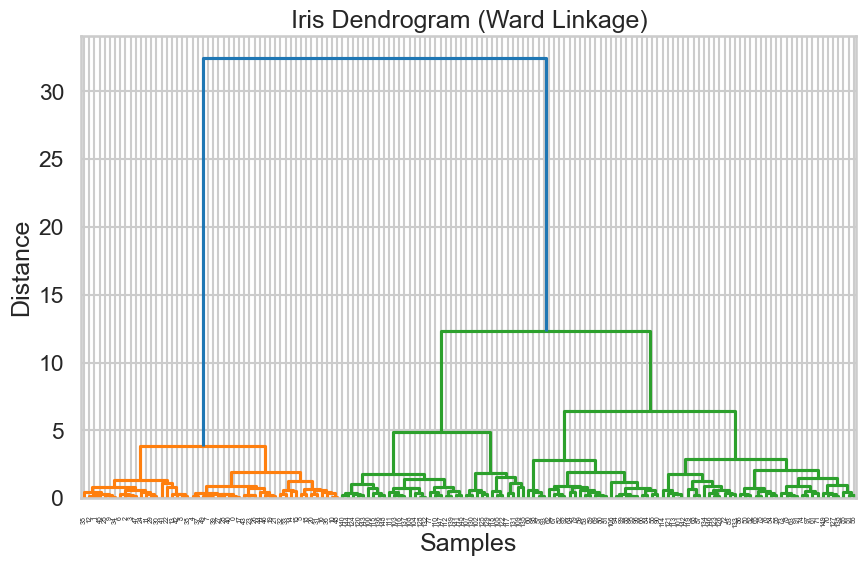

In [102]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage
plt.figure(figsize=(10, 6))
Z = linkage(X, method='ward')
dendrogram(Z)
plt.title("Iris Dendrogram (Ward Linkage)")
plt.xlabel("Samples")
plt.ylabel("Distance")
plt.show()


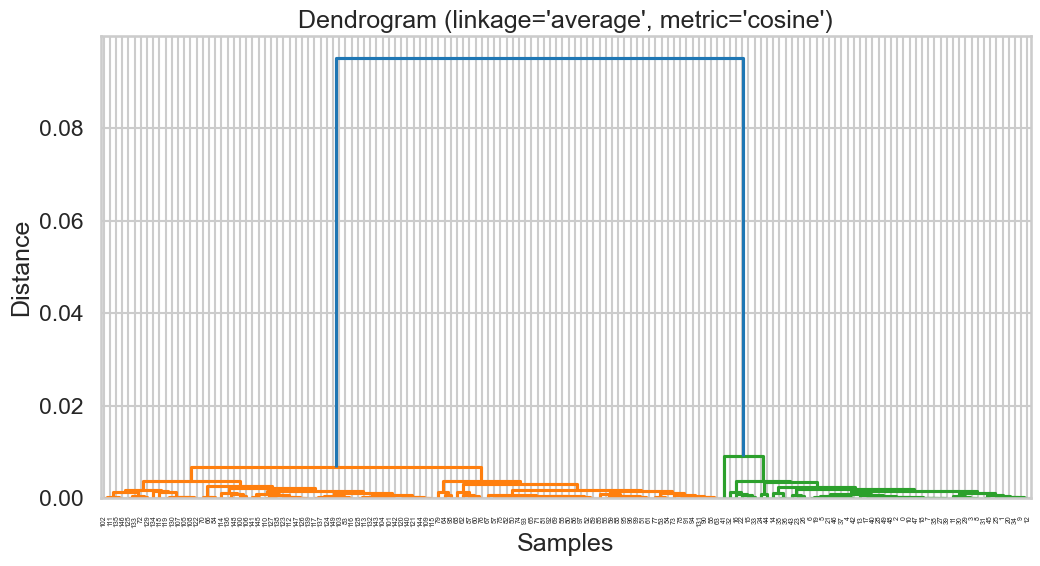

In [103]:
from scipy.cluster.hierarchy import linkage, dendrogram
import matplotlib.pyplot as plt

# Build linkage matrix for the best trial
Z = linkage(X, method='average', metric='cosine')

# Plot dendrogram
plt.figure(figsize=(12, 6))
dendrogram(Z)
plt.title("Dendrogram (linkage='average', metric='cosine')")
plt.xlabel("Samples")
plt.ylabel("Distance")
plt.show()

## Scaling

In [201]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score, adjusted_rand_score
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import math

# scale the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

metrics = ['euclidean', 'manhattan', 'cosine']
linkages = ['ward', 'complete', 'average', 'single']
Ks = range(3, 5)

results_scaled = []
plots_scaled = []

for metric in metrics:
    for link in linkages:
        for k in Ks:
            
            if link == 'ward' and metric != 'euclidean':
                continue
            
            try:
                model = AgglomerativeClustering(
                    n_clusters=k,
                    metric=metric,
                    linkage=link
                )
                
                labels = model.fit_predict(X_scaled)
                
                sil_score = silhouette_score(X_scaled, labels)
                ari_score = adjusted_rand_score(y_true, labels)
                
                results_scaled.append((metric, link, k, sil_score, ari_score, labels))
                plots_scaled.append((metric, link, k, sil_score, ari_score, labels))
            
            except Exception:
                continue

# choose best result based on silhouette score
best_scaled = max(results_scaled, key=lambda x: x[3])

print("Best scaled result based on silhouette score:")
print("Metric:", best_scaled[0])
print("Linkage:", best_scaled[1])
print("K:", best_scaled[2])
print("Silhouette Score:", best_scaled[3])
print("ARI:", best_scaled[4])



Best scaled result based on silhouette score:
Metric: euclidean
Linkage: single
K: 3
Silhouette Score: 0.504645610832545
ARI: 0.5583714437541352


The unscaled data produced better clustering performance for Agglomerative Clustering on the Iris dataset, achieving higher silhouette and ARI scores. This suggests that feature scaling is not always necessary when the dataset already contains features measured on similar scales.

In [189]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)
results_scaled = []

for n in range(2, 7):

    model = AgglomerativeClustering(n_clusters=n)
    labels = model.fit_predict(X_scaled)

    sil = silhouette_score(X_scaled, labels)

    results_scaled.append((n, sil, labels))

best_scaled = max(results_scaled, key=lambda x: x[1])

print("WITH SCALING")
print("Best n_clusters:", best_scaled[0])
print("Best silhouette:", best_scaled[1])

WITH SCALING
Best n_clusters: 2
Best silhouette: 0.5770346019475988


## DBSCAN

In [183]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris

iris = load_iris()

Z = iris.data
y_true = iris.target
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score

eps_values = np.arange(0.1, 3.1, 0.3)
min_samples_values = range(5, 26)

results1 = []

for eps in eps_values:
    for min_s in min_samples_values:

        model = DBSCAN(eps=eps, min_samples=min_s)
        labels = model.fit_predict(Z)

        if len(set(labels)) <= 1:
            continue

        if -1 in labels and len(set(labels)) <= 2:
            continue

        try:
            score = silhouette_score(Z, labels)
            results1.append((eps, min_s, score, labels))
            
        except:
            pass

In [185]:
best_result = max(results1, key=lambda x: x[2])

best_eps = best_result[0]
best_min_samples = best_result[1]
best_score = best_result[2]
best_labels = best_result[3]

print("Best EPS:", best_eps)
print("Best Min_samples:", best_min_samples)
print("Best Silhouette Score:", best_score)

Best EPS: 1.0000000000000002
Best Min_samples: 5
Best Silhouette Score: 0.6867350732769777


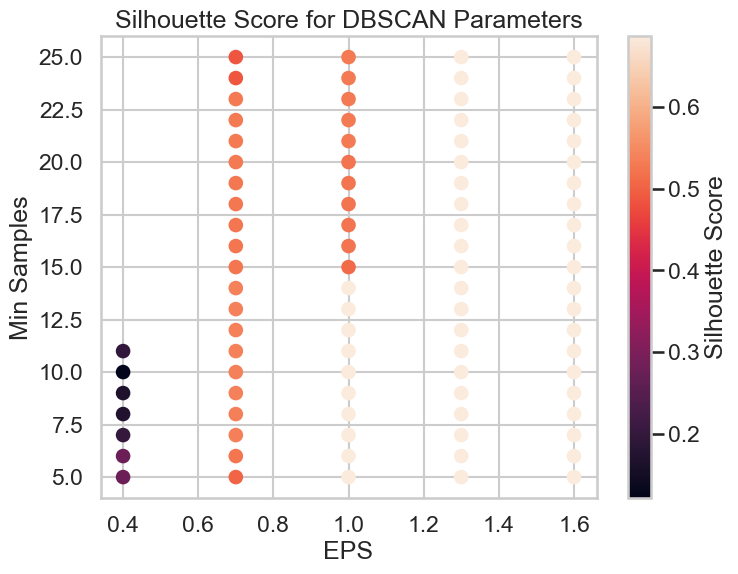

In [181]:
eps_list = [r[0] for r in results1]
min_samples_list = [r[1] for r in results1]
scores = [r[2] for r in results1]

plt.figure(figsize=(8,6))

scatter = plt.scatter(eps_list, min_samples_list, c=scores)

plt.xlabel("EPS")
plt.ylabel("Min Samples")
plt.title("Silhouette Score for DBSCAN Parameters")

plt.colorbar(scatter, label="Silhouette Score")

plt.show()

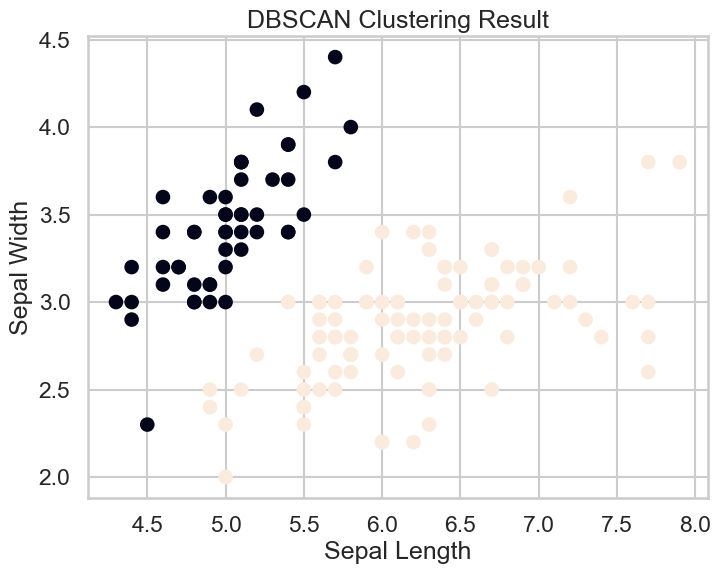

In [186]:
plt.figure(figsize=(8,6))

plt.scatter(
    Z[:,0],
    Z[:,1],
    c=best_labels
)

plt.xlabel("Sepal Length")
plt.ylabel("Sepal Width")
plt.title("DBSCAN Clustering Result")

plt.show()

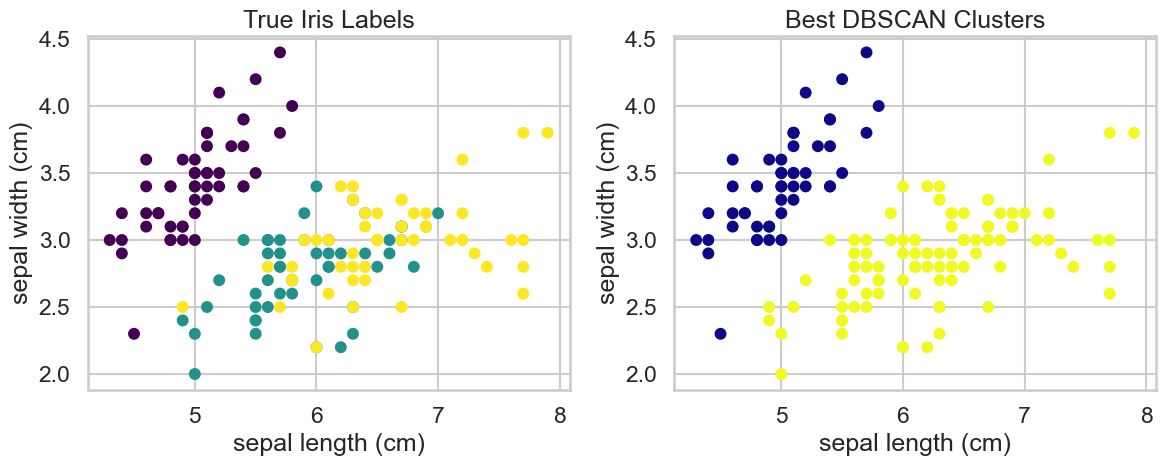

In [187]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(X[:, 0], X[:, 1], c=y_true, cmap="viridis", s=50)
plt.xlabel(iris.feature_names[0])
plt.ylabel(iris.feature_names[1])
plt.title("True Iris Labels")

plt.subplot(1, 2, 2)
plt.scatter(X[:, 0], X[:, 1], c=best_labels, cmap="plasma", s=50)
plt.xlabel(iris.feature_names[0])
plt.ylabel(iris.feature_names[1])
plt.title("Best DBSCAN Clusters")

plt.tight_layout()
plt.show()

## Scaling

In [188]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
Z_scaled = scaler.fit_transform(Z)
results_scaled = []

for eps in eps_values:
    for min_s in min_samples_values:

        model = DBSCAN(eps=eps, min_samples=min_s)
        labels = model.fit_predict(Z_scaled)

        clusters = set(labels) - {-1}

        if len(clusters) < 2:
            continue

        try:
            sil = silhouette_score(Z_scaled, labels)
            results_scaled.append((eps, min_s, sil, labels))
        except:
            continue

best_scaled = max(results_scaled, key=lambda x: x[2])

print("WITH SCALING")
print("Best EPS:", best_scaled[0])
print("Best min_samples:", best_scaled[1])
print("Best silhouette:", best_scaled[2])

WITH SCALING
Best EPS: 1.6000000000000003
Best min_samples: 5
Best silhouette: 0.5817500491982808


After scaling the data, the optimal EPS increased and the silhouette score decreased slightly. This indicates that feature scaling changed the density relationships in the dataset, but it did not improve clustering quality for the Iris dataset because the original features already had similar scales.

## Customer dataset
Repeat all the above on the customer data set

## Kmeans

In [206]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

# Load data
df1 = pd.read_csv(r"C:\Users\ganna\Downloads\Customer data.csv")

print(df1.head())
print(df1.shape)

# Drop ID column
df1 = df1.drop(columns=['ID'])
print("..........")
# Check missing values
print(df1.isnull().sum())



          ID  Sex  Marital status  Age  Education  Income  Occupation  \
0  100000001    0               0   67          2  124670           1   
1  100000002    1               1   22          1  150773           1   
2  100000003    0               0   49          1   89210           0   
3  100000004    0               0   45          1  171565           1   
4  100000005    0               0   53          1  149031           1   

   Settlement size  
0                2  
1                2  
2                0  
3                1  
4                1  
(2000, 8)
..........
Sex                0
Marital status     0
Age                0
Education          0
Income             0
Occupation         0
Settlement size    0
dtype: int64


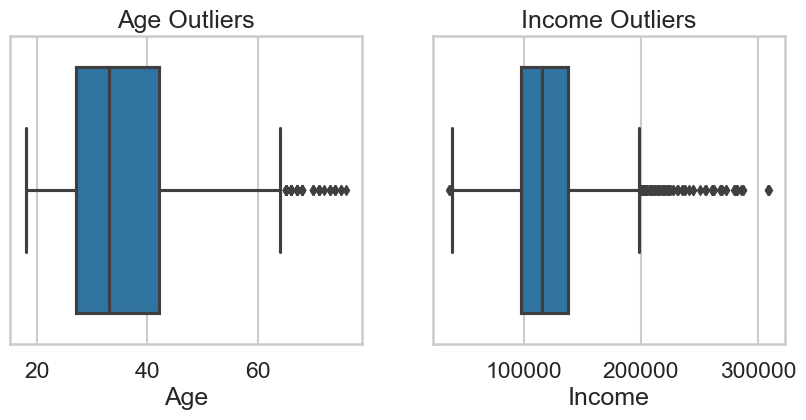

Outliers per column:
Age       57
Income    83
dtype: int64


In [209]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
sns.boxplot(x=df1["Age"])
plt.title("Age Outliers")

plt.subplot(1,2,2)
sns.boxplot(x=df1["Income"])
plt.title("Income Outliers")

plt.show()
import numpy as np

cols = ["Age", "Income"]

Q1 = df1[cols].quantile(0.25)
Q3 = df1[cols].quantile(0.75)

IQR = Q3 - Q1

outliers = ((df1[cols] < (Q1 - 1.5 * IQR)) |
            (df1[cols] > (Q3 + 1.5 * IQR)))

print("Outliers per column:")
print(outliers.sum())

In [253]:
K_range = range(2,11)

distortions = []
sil_scores = []

for k in K_range:

    model = KMeans(
        n_clusters=k,
        init='k-means++',
        n_init=10,
        random_state=42
    )

    labels1 = model.fit_predict(df1)

    distortions.append(model.inertia_)

    sil = silhouette_score(df1, labels1)
    sil_scores.append(sil)

    print(f"K = {k}")
    print("Distortion:", model.inertia_)
    print("Silhouette:", sil)
    print("Cluster counts:")
    print(pd.Series(labels1).value_counts())
    print("--------------")

K = 2
Distortion: 1214580027362.1714
Silhouette: 0.5834469001696239
Cluster counts:
0    1489
1     511
Name: count, dtype: int64
--------------
K = 3
Distortion: 673036781440.1227
Silhouette: 0.5125390340067693
Cluster counts:
0    898
1    889
2    213
Name: count, dtype: int64
--------------
K = 4
Distortion: 377110110166.3978
Silhouette: 0.5428478909695625
Cluster counts:
0    954
2    486
3    455
1    105
Name: count, dtype: int64
--------------
K = 5
Distortion: 248986947113.34946
Silhouette: 0.5401417522540799
Cluster counts:
0    719
4    562
2    366
1    280
3     73
Name: count, dtype: int64
--------------
K = 6
Distortion: 176783569738.74686
Silhouette: 0.5437793208348795
Cluster counts:
0    674
4    546
3    347
1    314
5     92
2     27
Name: count, dtype: int64
--------------
K = 7
Distortion: 129513456783.2465
Silhouette: 0.5324027895899586
Cluster counts:
1    558
0    465
3    371
4    278
5    218
2     83
6     27
Name: count, dtype: int64
--------------
K = 8
Di

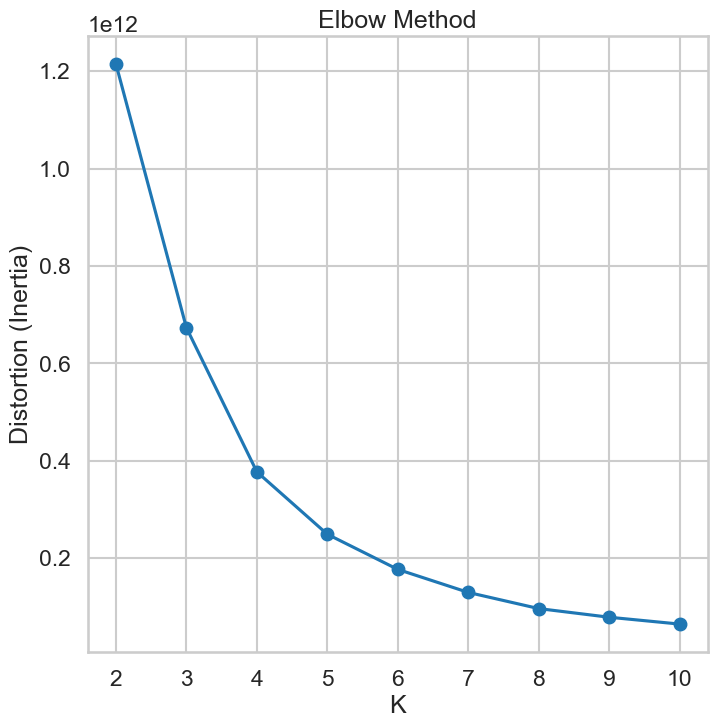

In [245]:
plt.figure()

plt.plot(K_range, distortions, marker='o')

plt.xlabel("K")
plt.ylabel("Distortion (Inertia)")
plt.title("Elbow Method")

plt.show()

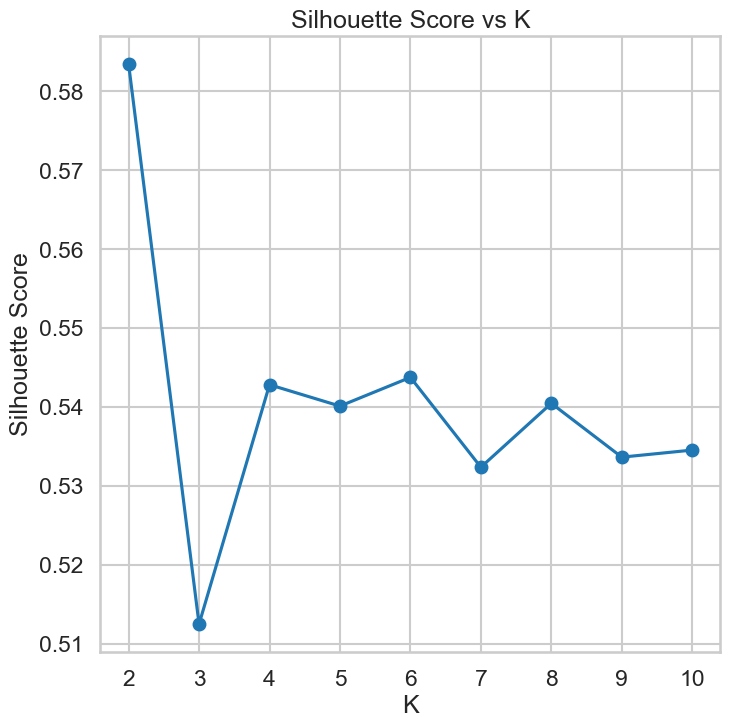

In [246]:
plt.figure()

plt.plot(K_range, sil_scores, marker='o')

plt.xlabel("K")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score vs K")

plt.show()

## with scaling

In [215]:
scaler = StandardScaler()

X_scaled1 = scaler.fit_transform(df1)
K_range = range(2,11)

distortions = []
sil_scores = []

for k in K_range:

    model = KMeans(
        n_clusters=k,
        init='k-means++',
        n_init=10,
        random_state=42
    )

    labels1 = model.fit_predict(X_scaled1)

    distortions.append(model.inertia_)

    sil = silhouette_score(X_scaled1, labels1)
    sil_scores.append(sil)

    print(f"K = {k}")
    print("Distortion:", model.inertia_)
    print("Silhouette:", sil)
    print("Cluster counts:")
    print(pd.Series(labels1).value_counts())
    print("--------------")

K = 2
Distortion: 10514.558847734455
Silhouette: 0.2496082794803034
Cluster counts:
0    1123
1     877
Name: count, dtype: int64
--------------
K = 3
Distortion: 8630.913216898227
Silhouette: 0.27177060998494357
Cluster counts:
2    866
1    859
0    275
Name: count, dtype: int64
--------------
K = 4
Distortion: 7169.870822465846
Silhouette: 0.26879180394522123
Cluster counts:
2    705
3    570
1    462
0    263
Name: count, dtype: int64
--------------
K = 5
Distortion: 6403.134167928613
Silhouette: 0.2540800397305643
Cluster counts:
1    476
0    468
3    453
4    357
2    246
Name: count, dtype: int64
--------------
K = 6
Distortion: 5830.956302961155
Silhouette: 0.2630752333415311
Cluster counts:
0    464
1    434
3    427
2    348
5    171
4    156
Name: count, dtype: int64
--------------
K = 7
Distortion: 5378.854705323013
Silhouette: 0.26659241496996416
Cluster counts:
0    427
6    375
1    359
2    347
4    190
5    155
3    147
Name: count, dtype: int64
--------------
K = 8
D

In [247]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Unscaled
kmeans_unscaled = KMeans(n_clusters=4, random_state=42)
labels_unscaled = kmeans_unscaled.fit_predict(df1)
sil_kmeans_unscaled = silhouette_score(df1, labels_unscaled)

# Scaled
kmeans_scaled = KMeans(n_clusters=4, random_state=42)
labels_scaled = kmeans_scaled.fit_predict(X_scaled)
sil_kmeans_scaled = silhouette_score(X_scaled, labels_scaled)

print("KMeans Unscaled Silhouette:", sil_kmeans_unscaled)
print("KMeans Scaled Silhouette:", sil_kmeans_scaled)

KMeans Unscaled Silhouette: 0.5428478909695625
KMeans Scaled Silhouette: 0.26879180394522123


KMeans relies on Euclidean distance and cluster centroids (means).

In the unscaled dataset:

variables with larger ranges (e.g., Income) dominate the distance calculation

those variables may strongly separate customer groups

clusters become clearer

After scaling:

all variables contribute equally

weaker variables dilute the separation

cluster boundaries become less distinct

silhouette score decreases

In [250]:
# 4 is the best, distortion starts to decrease and good sil score
from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=4,
    init='k-means++',
    n_init=10,
    random_state=42
)

labels = kmeans.fit_predict(df1)
from sklearn.decomposition import PCA

pca = PCA(n_components=3)

X_pca = pca.fit_transform(df1)


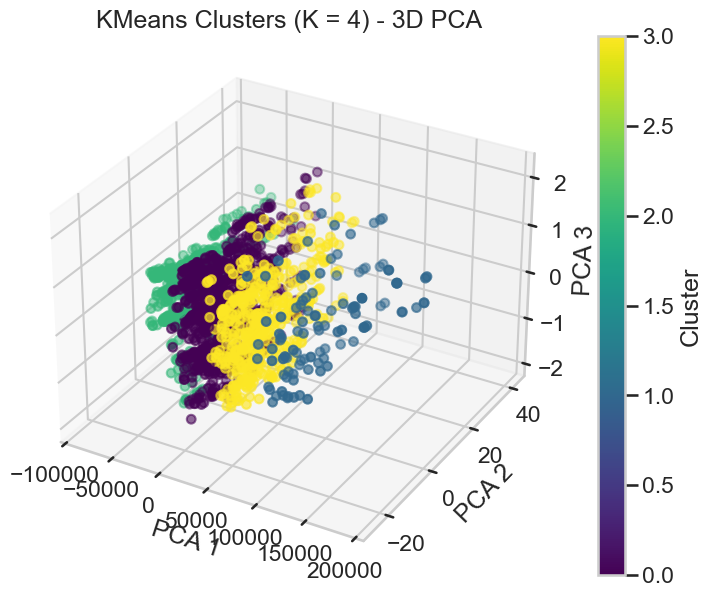

In [251]:
#plotting the 4 clusters
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(10,7))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(
    X_pca[:,0],
    X_pca[:,1],
    X_pca[:,2],
    c=labels,
    cmap='viridis',
    s=40
)

ax.set_title("KMeans Clusters (K = 4) - 3D PCA")
ax.set_xlabel("PCA 1")
ax.set_ylabel("PCA 2")
ax.set_zlabel("PCA 3")

plt.colorbar(scatter, label="Cluster")

plt.show()

## Hierarchical

In [254]:
metrics = ['euclidean', 'manhattan', 'cosine']
linkages = ['ward', 'complete', 'average', 'single']
Ks = range(2,11)

results = []

for metric in metrics:
    for link in linkages:
        for k in Ks:

            if link == 'ward' and metric != 'euclidean':
                continue

            try:
                model = AgglomerativeClustering(
                    n_clusters=k,
                    metric=metric,
                    linkage=link
                )

                labels2 = model.fit_predict(df1)

                sil = silhouette_score(df1, labels2)

                results.append({
                    "metric": metric,
                    "linkage": link,
                    "k": k,
                    "silhouette": sil
                })

                print(f"Metric: {metric} | Linkage: {link} | K: {k} | Silhouette: {sil}")

            except:
                pass

Metric: euclidean | Linkage: ward | K: 2 | Silhouette: 0.5682214238395729
Metric: euclidean | Linkage: ward | K: 3 | Silhouette: 0.5285291371414573
Metric: euclidean | Linkage: ward | K: 4 | Silhouette: 0.5317617689963741
Metric: euclidean | Linkage: ward | K: 5 | Silhouette: 0.5298858015643996
Metric: euclidean | Linkage: ward | K: 6 | Silhouette: 0.5130493911739391
Metric: euclidean | Linkage: ward | K: 7 | Silhouette: 0.48577363736918694
Metric: euclidean | Linkage: ward | K: 8 | Silhouette: 0.4981923732112335
Metric: euclidean | Linkage: ward | K: 9 | Silhouette: 0.5078285220644706
Metric: euclidean | Linkage: ward | K: 10 | Silhouette: 0.5020078008156543
Metric: euclidean | Linkage: complete | K: 2 | Silhouette: 0.6886613652069382
Metric: euclidean | Linkage: complete | K: 3 | Silhouette: 0.458237935891215
Metric: euclidean | Linkage: complete | K: 4 | Silhouette: 0.5287025515975695
Metric: euclidean | Linkage: complete | K: 5 | Silhouette: 0.5217587729361148
Metric: euclidean | L

In [255]:
results_df = pd.DataFrame(results)

best_result = results_df.loc[results_df['silhouette'].idxmax()]

print("\nBest Result:")
print(best_result)


Best Result:
metric        euclidean
linkage          single
k                     2
silhouette     0.758568
Name: 27, dtype: object


best: Metric = euclidean
      Linkage = average
      K = 3
      Silhouette ≈ 0.571

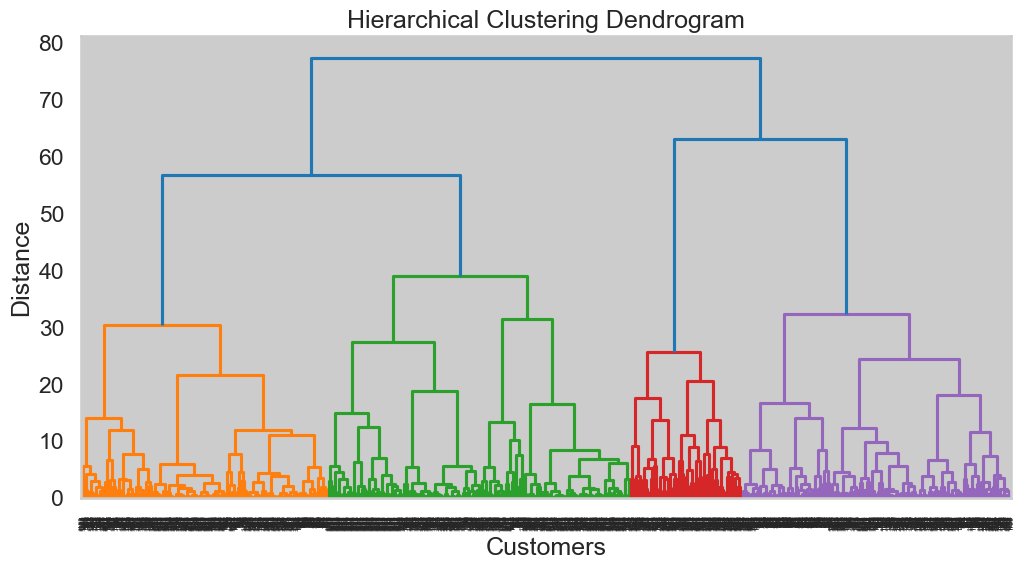

In [256]:
Z = linkage(X_scaled1, method='ward', metric='euclidean')

plt.figure(figsize=(12,6))

dendrogram(Z)

plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Customers")
plt.ylabel("Distance")

plt.show()

## with scaling

In [257]:
metrics = ['euclidean', 'manhattan', 'cosine']
linkages = ['ward', 'complete', 'average', 'single']
Ks = range(2,11)

results = []

for metric in metrics:
    for link in linkages:
        for k in Ks:

            if link == 'ward' and metric != 'euclidean':
                continue

            try:
                model = AgglomerativeClustering(
                    n_clusters=k,
                    metric=metric,
                    linkage=link
                )

                labels2 = model.fit_predict(X_scaled1)

                sil = silhouette_score(X_scaled1, labels2)

                results.append({
                    "metric": metric,
                    "linkage": link,
                    "k": k,
                    "silhouette": sil
                })

                print(f"Metric: {metric} | Linkage: {link} | K: {k} | Silhouette: {sil}")

            except:
                pass

Metric: euclidean | Linkage: ward | K: 2 | Silhouette: 0.23099458010188773
Metric: euclidean | Linkage: ward | K: 3 | Silhouette: 0.24932369297836884
Metric: euclidean | Linkage: ward | K: 4 | Silhouette: 0.25080894270462684
Metric: euclidean | Linkage: ward | K: 5 | Silhouette: 0.261944083191251
Metric: euclidean | Linkage: ward | K: 6 | Silhouette: 0.25794561218330625
Metric: euclidean | Linkage: ward | K: 7 | Silhouette: 0.25485522014739065
Metric: euclidean | Linkage: ward | K: 8 | Silhouette: 0.2815579883309501
Metric: euclidean | Linkage: ward | K: 9 | Silhouette: 0.3016137339305145
Metric: euclidean | Linkage: ward | K: 10 | Silhouette: 0.31286631510337204
Metric: euclidean | Linkage: complete | K: 2 | Silhouette: 0.1296540284177961
Metric: euclidean | Linkage: complete | K: 3 | Silhouette: 0.13117636740125446
Metric: euclidean | Linkage: complete | K: 4 | Silhouette: 0.13745941906727507
Metric: euclidean | Linkage: complete | K: 5 | Silhouette: 0.18379182809557246
Metric: eucli

best in scaled = 5 clusters
hierarchical_best_metric = "euclidean"
hierarchical_best_linkage = "ward"

Hierarchical clustering also depends on distance calculations.

In particular with Ward linkage, the algorithm minimizes within-cluster variance.

When the data is scaled:

the natural variance differences between variables disappear

the algorithm cannot exploit strong features as effectively

cluster separation weakens

This can lead to lower silhouette scores.

## DBSCAN

In [261]:
eps_values = np.arange(0.1, 3.1, 0.2)
min_samples_values = range(5, 26)

results = []

for eps in eps_values:
    for min_s in min_samples_values:

        model = DBSCAN(eps=eps, min_samples=min_s)

        labels = model.fit_predict(X_scaled1)

        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)

        # Keep only solutions with <= 10 clusters
        if 2 <= n_clusters <= 10:

            score = silhouette_score(X_scaled1, labels)

            results.append({
                "eps": eps,
                "min_samples": min_s,
                "clusters": n_clusters,
                "silhouette": score
            })

            print(f"EPS={eps} | min_samples={min_s} | clusters={n_clusters} | silhouette={score}")

EPS=0.1 | min_samples=9 | clusters=9 | silhouette=-0.22423567228644142
EPS=0.1 | min_samples=10 | clusters=8 | silhouette=-0.24243378435562343
EPS=0.30000000000000004 | min_samples=18 | clusters=9 | silhouette=-0.10589271851270261
EPS=0.30000000000000004 | min_samples=19 | clusters=9 | silhouette=-0.11377323997274348
EPS=0.30000000000000004 | min_samples=20 | clusters=6 | silhouette=-0.125324571618451
EPS=0.30000000000000004 | min_samples=21 | clusters=7 | silhouette=-0.15387577911347347
EPS=0.30000000000000004 | min_samples=22 | clusters=7 | silhouette=-0.16558030921846353
EPS=0.30000000000000004 | min_samples=23 | clusters=6 | silhouette=-0.14631449096893895
EPS=0.30000000000000004 | min_samples=24 | clusters=6 | silhouette=-0.15362199726806905
EPS=0.30000000000000004 | min_samples=25 | clusters=6 | silhouette=-0.15878167202614077
EPS=1.7000000000000004 | min_samples=5 | clusters=4 | silhouette=0.17760230988900047
EPS=1.7000000000000004 | min_samples=6 | clusters=4 | silhouette=0.177

In [262]:
results_df = pd.DataFrame(results)

best_result = results_df.loc[results_df["silhouette"].idxmax()]

print(best_result)

eps             1.700000
min_samples    18.000000
clusters        4.000000
silhouette      0.189941
Name: 23, dtype: float64


DBSCAN did not print anything with unscaled data, meaning the if condition is not even satisfied, the dataset likely has features with very different scales (for example Income vs Age).


DBSCAN is extremely sensitive to feature scale, so the distances become distorted.

As a result:

small eps → everything becomes noise

large eps → everything becomes one cluster